In [1]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

# 분자의 3차원 구조 생성하기

* 일반적으로 분자의 다양한 3차원 구조를 가질 수 있다.

* 하나의 회전 가능한 단일 결합의 경우 매우 단순하게 생각해도 trans/gauch+/gauch- 세가지의 가능성을 가질 수 있다.

* 이는 만일 분자가 회전 가능한 단일 결합을 10개를 가지고 있다고 하면 3^10 개의 가능성을 가지고 있다는 뜻이 된다.

* 그러므로 가장 낮은 에너지를 가지는 3차원 구조를 얻는 것은 매우 계산 시간이 오래 걸리는 일이다.

* 일반적으로는 이를 해결하기 위해서 다양한 가정을 도입하여 근사적으로 최적의 에너지 구조를 얻는다.

* RDKit에서는 실험 데이터에서 힌트를 얻어 3D 구조를 생성하는 자체적인 ETDKG 방법을 가지고 있다.

* ref: https://www.rdkit.org/docs/GettingStartedInPython.html#working-with-3d-molecules

* 분자의 개수가 적다면 Corina와 같은 webserver를 이용할 수 있다.

* https://www.mn-am.com/online_demos/corina_demo

In [2]:
m = Chem.MolFromSmiles('C1CCC1OC')

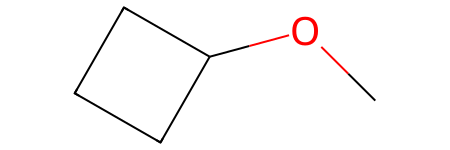

In [3]:
m

=> 수소 포함하지 않은 구조

In [4]:
m2 = Chem.AddHs(m)

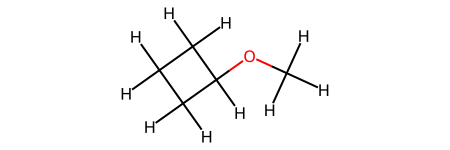

In [5]:
m2

## 1. EmbedMolecule

In [6]:
# AllChem의 EmbedMolecule 메쏘드를 이용해서 분자의 3차원 구조를 계산한다.
AllChem.EmbedMolecule(m2)

0

=> Error 없이 3차원 구조가 생성되면 0, 그렇지 않으면 다른 값이 리턴됨.

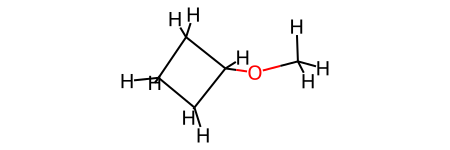

In [7]:
m2

## 2. MMFFOptimizedMolecule

=> EmbedMolecule로 얻은 3차원 구조는 근사적인 3차원 구조이다.

* MMFF force field를 이용하여 한 번 더 최적화를 수행한다
* force field는 양자역학적인 계산이 아니라 parameter 적으로 'sp3 carbon과 sp3 carbon 사이에 어느정도 되어야한다. 각도는 어느정도 되야야한다.'를 parameter화 시켜 놓은것.

=> AllChem.MMFFOptimizeMolecule(x)


In [8]:
AllChem.MMFFOptimizeMolecule(m2)

0

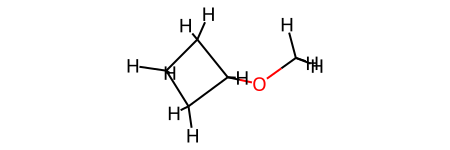

In [9]:
m2

## 3. EmbedMultipleConfs
> 여러개의 3차원 구조 생성하기

* 예상되는 최적의 구조 뿐만 아니라 다양한 3차원 구조를 얻어야 하는 경우가 많이 있다. (Conformational isomer)

* 이럴 때는 EmbedMultipleConfs 메쏘드를 사용하면 된다.

  => cids = AllChem.EmbedMultipleConfs(m2, numConfs=10)

In [11]:
m = Chem.MolFromSmiles('C1CCC1OC')

In [12]:
m2 = Chem.AddHs(m)

In [14]:
# 10개의 구조를 생성한다.
# numConfs = n : n개의 conformational isomer를 생성하라는 의미
cids = AllChem.EmbedMultipleConfs(m2, numConfs=10)

In [17]:
cids

=> cids는 일종의 벡터 형식

In [16]:
print(len(cids))

10


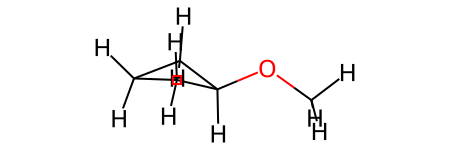

In [18]:
m2 # 첫번째 3D 구조 확인

### 3-1) Chem.MolToMolBlock, Chem.MolToMolFile, Chem.MolToPDBFile

* 여러개의 구조를 출력하기 위해서는 MolToMolBlock, MolToMolFile, MolToPDBFile 등의 method에서 confId 옵션을 사용하면 된다.

  => print(Chem.MolToMolBlock(m2, confId=n))
  여기서 confId = n 의 n 은 n 번째 분자를 의미.
  2번째 분자를 출력하려면 print(Chem.MolToMolBlock(m2, confId=2))
  6번째 분자를 출력하려면 print(Chem.MolToMolBlock(m2, confId=6))
  9번째 분자를 출력하려면 print(Chem.MolToMolBlock(m2, confId=9))
  를 입력하면된다.

In [19]:
print(Chem.MolToMolBlock(m2, confId=3))


     RDKit          3D

 16 16  0  0  0  0  0  0  0  0999 V2000
   -0.8387   -1.0873   -0.3533 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9439   -0.1174    0.0664 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9467    0.9904   -0.2837 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.1165   -0.0075    0.1352 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.2749    0.1307   -0.5845 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.4287    0.1676    0.1885 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.8732   -1.9853    0.2998 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9141   -1.2272   -1.4329 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.8567   -0.1566   -0.5288 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.0695   -0.0593    1.1820 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.8819    1.1701   -1.3770 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9843    1.8758    0.3721 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.2051   -0.0748    1.2305 H   0  0  0  0  0  0  0  0  0  0  0  0
    3.3025    0.2811   -0

In [20]:
print(Chem.MolToMolBlock(m2, confId=9))


     RDKit          3D

 16 16  0  0  0  0  0  0  0  0999 V2000
   -1.0472    1.0222   -0.3072 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7059   -0.2763    0.1838 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.6844   -0.9556   -0.7286 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.2319    0.2096   -0.3197 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7229   -0.0904    0.9450 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.1144    0.0374    0.8667 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.1010    1.8670    0.3849 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3880    1.2059   -1.3494 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.7544   -0.3998   -0.0719 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.4328   -0.4667    1.2499 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.3277   -1.9472   -0.3926 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0528   -0.8661   -1.7616 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.9822    0.4694   -1.0763 H   0  0  0  0  0  0  0  0  0  0  0  0
    2.4975   -0.6891    0

## 4. AllChem.AlignMolConformers

> conformational isomer 사이의 구조 차이는 RMSD(root mena square deviation)로 확인한다.

> All.Chem.AlignMolConformers(m, RMSlist= n or list 이름)

In [21]:
rmslist = []
AllChem.AlignMolConformers(m2, RMSlist=rmslist)
print(len(rmslist))

9


### 4-1) AllChem.GetConformerRMS

* 첫번째 conformer와 나머지 conformer 사이의 RMSD 계산.

  => 몇 A 차이가 나는지?

In [22]:
print(rmslist)

[1.2057060786227738, 1.201622097730382, 1.2767719132157482, 1.3402749924265147, 0.822684125223078, 0.7592677420071279, 0.9900373279811209, 1.0614064777188665, 1.4737755336893974]


* 특정 conformer 사이의 rms 계산하고자 할때.

* 예를 들어 1번과 9번 사이의 rms 계산을 수행하고자 할때.

* AllChem.GetConformerRMS 사용.

  => AllChem.GetConformorRMS(x, n, m, prealigned=True)

  해석: x의 n번째 conformer와 m번째 conformer 사이에 prealigned(미리 aligned된 구조를 사용할 것인지)

In [24]:
rms = AllChem.GetConformerRMS(m2, 2, 9, prealigned=True)

In [25]:
rms

1.217173598743264

## 5. AllChem.MMFFOptimizeMoleculeConfs
> 여러개 conformer들의 에너지를 최소화시킬 수 있다.

In [26]:
result = AllChem.MMFFOptimizeMoleculeConfs(m2)

* (n, m)의 의미
* n: n=0 이라면 계산이 수렴되었다는 의미, n=1 이라면 수렴하지 않았다.
* m: 에너지 값. 값이 비슷하면 서로서로 비슷하다고 예측가능

In [27]:
 print(result)

[(0, 10.728830580468088), (0, 10.728830577417803), (0, 10.728830579318906), (0, 10.728830579174039), (0, 11.677582321673437), (0, 10.728830583497306), (0, 10.728830580995586), (0, 10.728830577951127), (0, 10.728830577777648), (0, 11.677582321342744)]


In [28]:
print(len(result))

10


In [32]:
# optimize된 3차원 구조 출력
print(Chem.MolToMolBlock(m2, confId=9))


     RDKit          3D

 16 16  0  0  0  0  0  0  0  0999 V2000
   -1.2317    0.2366    1.0690 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7832   -0.2448   -0.2849 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.6100    0.4918   -0.9562 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.1501    0.3865    0.3885 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.0364   -0.7454    0.5423 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.3142   -0.6181   -0.0646 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.2903   -0.4929    1.8812 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.6573    1.1862    1.4129 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.7818    0.1136   -0.5464 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7491   -1.3330   -0.4116 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1658   -0.0285   -1.8087 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.8386    1.5226   -1.2503 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.6613    1.3118    0.6801 H   0  0  0  0  0  0  0  0  0  0  0  0
    2.2105   -0.4803   -1

In [30]:
print(Chem.MolToMolFile(m2, confId=9))

ArgumentError: Python argument types in
    rdkit.Chem.rdmolfiles.MolToMolFile(Mol)
did not match C++ signature:
    MolToMolFile(class RDKit::ROMol mol, class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > filename, bool includeStereo=True, int confId=-1, bool kekulize=True, bool forceV3000=False)
    MolToMolFile(class RDKit::ROMol mol, class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > filename, struct RDKit::MolWriterParams params, int confId=-1)

### Troubleshooting

m2가 mol file형식이 아니라 문자열(mol block) 형식이기 때문에 발생한 오류

* 중요 

MMFF로 얻은 3차원 구조가 실제와 동일하다고 생각하면 안됨.
에너지가 낮은 구조를 얻기 위해서는 양자역학적 계산이 필요한데 오래걸리기 때문에 forcefield 사용하는 것

# 분자 구조식 그리기

> cdk2.sdf 파일: https://raw.githubusercontent.com/rdkit/rdkit/master/Docs/Book/data/cdk2.sdf

> ref: https://www.rdkit.org/docs/GettingStartedInPython.html#drawing-molecules

In [34]:
# 그림을 그리기 위해서 Chem의 하위 모듈이 Draw import
from rdkit.Chem import Draw

In [41]:
suppl = Chem.SDMolSupplier("data/cdk2.sdf")

In [44]:
# list comprehension을 이용해서 분자의 리스트를 얻는다. 
ms = [x for x in suppl if x is not None]
for m in ms:
    tmp=AllChem.Compute2DCoords(m)  # Compute2DCoords 를 사용하는 이유는 그림이 더 예쁘게 나오게 하기 위함.   

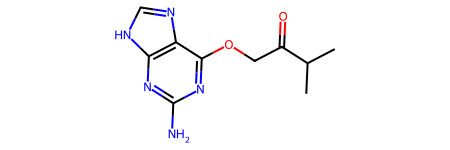

In [43]:
ms[0]

## 1. 그림 파일을 분자로 출력 (그리기)
> Draw.MolToFile(ms[1],'cdk2_mol2.o.png')
> ms[1]이라는 분자를 png 파일 형식으로 내보낸다.

In [47]:
Draw.MolToFile(ms[0],'data/cdk2_mol1.o.png')

In [48]:
Draw.MolToFile(ms[1],'data/cdk2_mol2.o.png')

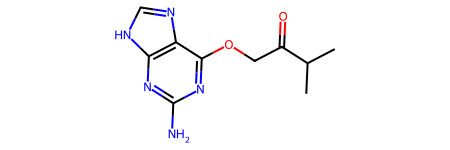

In [49]:
ms[0]

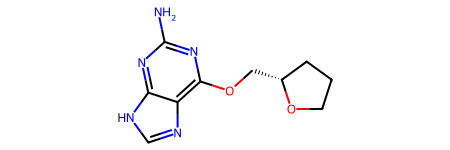

In [51]:
ms[1]

## 2. 여러개의 분자 구조를 한 파일에 그리기
> Draw.MolsToGridImage 함수를 이용

In [54]:
img=Draw.MolsToGridImage(ms[:8],
                         molsPerRow=4, # 한 행에 몇 개의 분자를 그릴 것인지? 
                         subImgSize=(200,200), # 각 이미지의 크기. 
                         legends=[x.GetProp("_Name") for x in ms[:8]]) # 밑에 설명을 어떻게 달 것인지. string("_Name")의 리스트 받는다. 

In [53]:
type(img)

IPython.core.display.Image

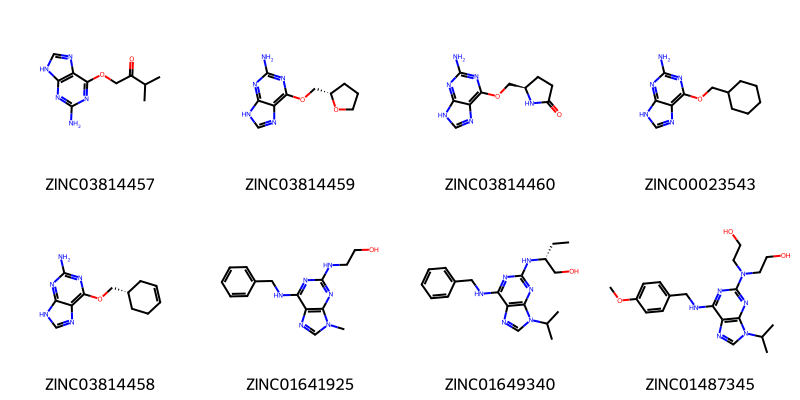

In [55]:
img

### 2-1) 공통된 구조를 이용해서 정렬하기
> 공통된 구조를 core structure라 부른다.

> 특정 core 구조를 가지는 분자만 선택.

> Mol-type class의 HasSubstructMatch 메소드를 이용해서 특정 core 구조를 가지는지 알 수 있다.

#### 2-1-1) core structure 지정

In [56]:
# core structure 지정
p = Chem.MolFromSmiles('[nH]1cnc2cncnc21')

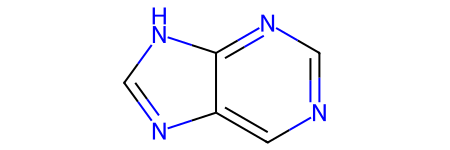

In [57]:
p

In [58]:
subms = [x for x in ms if x.HasSubstructMatch(p)]

In [59]:
len(subms)

14

In [60]:
len(ms)

47

=> 원래 있는 ms file에는 47개의 분자가 존재하는데 p라는 core structure를 공통으로 가지는 분자를 나타내는 subms 리스트에는 14개의 분자 존재

#### 2-1-2) core를 이용하여 정렬하기
> GenerateDepictionMatching2DStructure 사용

In [63]:
AllChem.Compute2DCoords(p)

0

In [64]:
# subms에 존재하는 분자(core structure를 가지는)를 하나씩 꺼낸다.
for m in subms:
    _ = AllChem.GenerateDepictionMatching2DStructure(m,p)

In [65]:
# 14개의 공통된 코어 구조를 가진 분자의 그림 생성. 
img=Draw.MolsToGridImage(subms,
                         molsPerRow=3,
                         subImgSize=(400, 400),
                         legends=[x.GetProp("_Name") for x in subms])

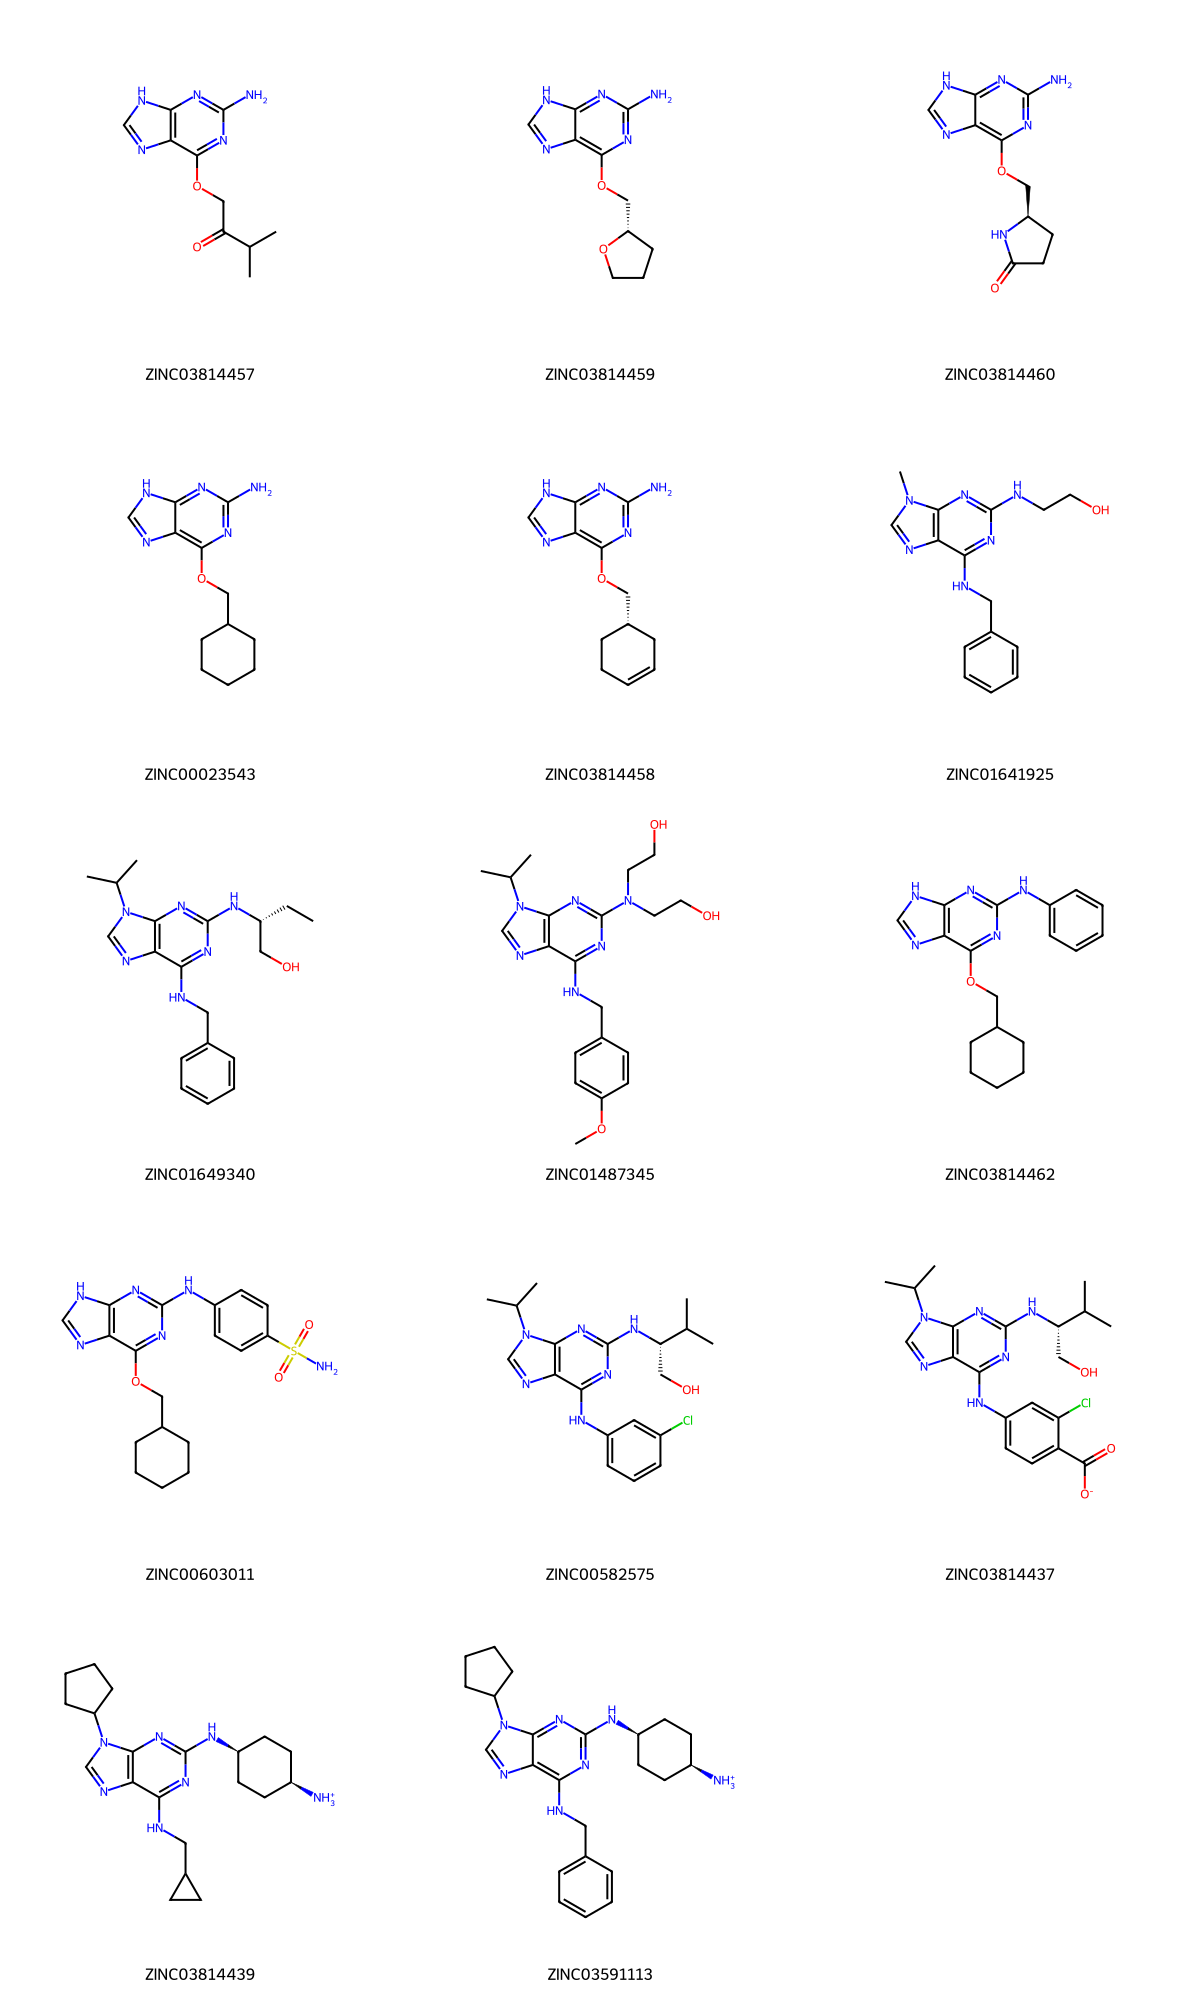

In [66]:
img

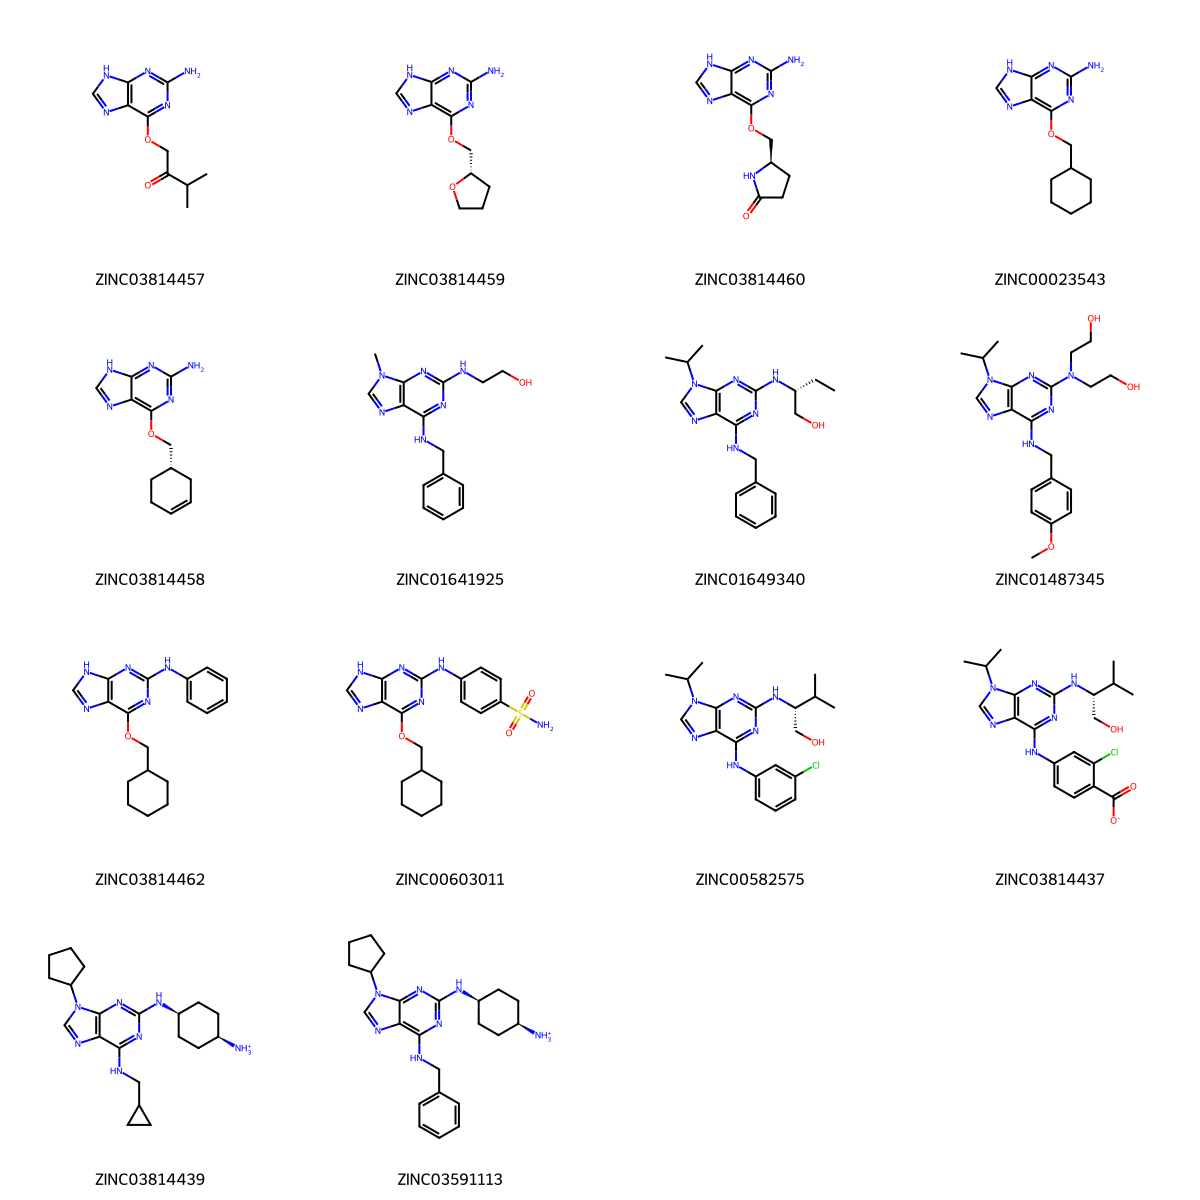

In [68]:
img=Draw.MolsToGridImage(subms,
                         molsPerRow=4,
                         subImgSize=(300, 300),
                         legends=[x.GetProp("_Name") for x in subms])
img

### 2-2) 임의의 label과 함께 출력하기
> 기존에는 legends=[x.GetProp("_Name") for x in subms 을 통해 리스트에 있는 label 그대로를 사용함

> 예제: logP 값을 label로 만들어서 출력.
logP 계산 함수: https://www.rdkit.org/docs/source/rdkit.Chem.Crippen.html

> SetProp 함수로 property(name) 설정
m.SetProp("LogP", f"logP: {logp:.3f}")
> * LogP : property 이름을
> * f"logP: [logp:.33f}로 정의하겠다

In [69]:
from rdkit.Chem.Crippen import MolLogP
for m in subms:     # subms에 있는 분자들을 하나씩 꺼내서
    logp = MolLogP(m)     # MolLopP() 함수에 넣으면 logp가 return
    print(logp)     # logp 출력
    m.SetProp("LogP", f"logP: {logp:.3f}") # property 설정할 때는 string(글자 데이터)으로 넣어주어야 한다. 

0.5389999999999999
0.4928999999999992
-0.40750000000000036
1.8941999999999999
1.6702
1.3795999999999995
3.2021000000000015
1.8188999999999997
4.055600000000002
2.702999999999999
4.233000000000002
2.5965
2.7283
3.5185000000000004


+ 추가 정보
  
  f-string 이라는 문법으로 문자열 안에 변수를 집어넣을 수 있게 해주는 기능
  
  f"logP: {logp:.3f}"
  > f: 문자 시작 따옴표 앞에 붙인다. "이 문자열 안에 변수가 들어갈거야"라고 파이썬에게 알려주는 신호.
  
  > {logp}: 중괄호{} 안에 변수 이름을 넣으면, 그 자리에 실제 변수 값이 치환되어 들어간다.
  
  > :.3f: 변수의 출력 형식을 지정하는 포맷터로
  >> .3: 은 소수점 아래 세 자리까지 포시해라.
  >> 
  >> f: 실수(Float) 형실으로 보여줘라.  

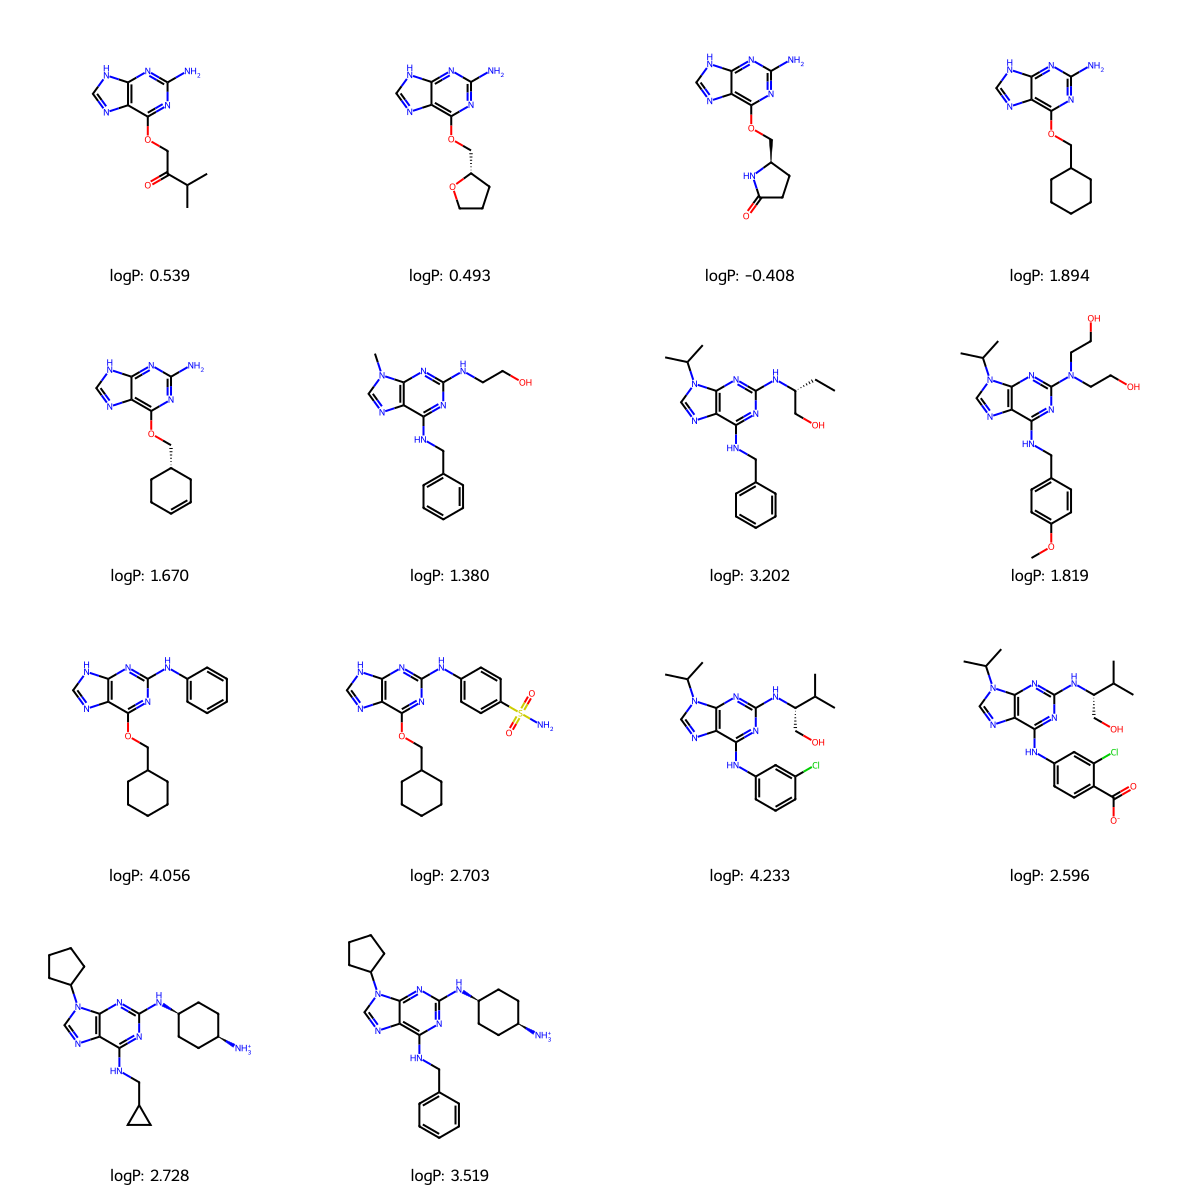

In [70]:
# x.GetProp() 괄호 속 label 이름 적기
img=Draw.MolsToGridImage(subms,
                         molsPerRow=4,
                         subImgSize=(300, 300),
                         legends=[x.GetProp("LogP") for x in subms])
img

## 3. Advanced drawing

* Customized picture를 만들기 위해서 다음 두가지 class를 사용할 수 있다.
* rdMolDraw2D.MolDraw2DSVG --> SVG 파일을 만들 때.
* rdMolDraw2D.MolDraw2DCairo --> PNG 파일을 만들 때.

### 3-1) 특정 구조에 highlight 추가
> from rdkit.Chem.Draw import rdMolDraw2D

In [71]:
from rdkit.Chem.Draw import rdMolDraw2D

In [72]:
smi = 'c1cc(F)ccc1Cl'
mol = Chem.MolFromSmiles(smi)
patt = Chem.MolFromSmarts('ClccccF')

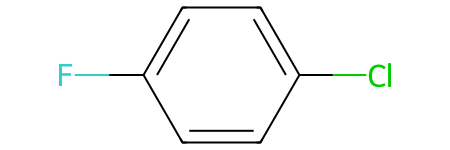

In [73]:
mol

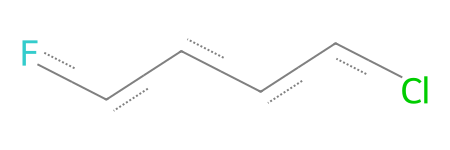

In [74]:
patt

In [75]:
# substructure match를 찾을때 => 화학 정보학(Cheminformatics)에서 거대한 분자 데이터베이스 내에서 특정 분자 구조(Substructure)를 포함하는 화합물만을 찾아내는 검색 방식
hit_ats = list(mol.GetSubstructMatch(patt))

In [76]:
hit_ats

[7, 6, 5, 4, 2, 3]

In [77]:
# substructure match(parttern)에 해당하는 bond 찾기
hit_bonds = []
for bond in patt.GetBonds():     # bond에 해당하는 것들 중
    aid1 = hit_ats[bond.GetBeginAtomIdx()]     # bond가 시작하는 atom의 index
    aid2 = hit_ats[bond.GetEndAtomIdx()]       # bond가 끝나는 atom의 index
    hit_bonds.append(mol.GetBondBetweenAtoms(aid1,aid2).GetIdx())     # atom idx 1(aid1)과 atom idx 2(aid2) 사이의 bond를 가져오고, 그 인덱스를 얻어낸다.(GetIdx())
print(hit_bonds)

[6, 5, 4, 3, 2]


### 3-2) 특정 구조에 highlight 추가한 분자(SVG 파일) 그림으로 출력
> SVG 파일로 저장하기 위해서 rdMolDraw2D.MolDraw2DSVG 를 사용한다.
>
> 주의: RDKit 2020.3 버젼 이후로 적용.

In [80]:
# d라는 canvas 생성
d = rdMolDraw2D.MolDraw2DSVG(500, 500) # or MolDraw2DCairo to get PNGs

In [81]:
# 실제 그림을 그리는 method
rdMolDraw2D.PrepareAndDrawMolecule(d, mol, highlightAtoms=hit_ats,
                                    highlightBonds=hit_bonds)

In [83]:
# FinishDrawing 메쏘드를 불러야 그림 완성됨.
d.FinishDrawing()

In [84]:
# SVG 파일은 실제로 텍스트 파일임.
print(d.GetDrawingText())

<?xml version='1.0' encoding='iso-8859-1'?>
<svg version='1.1' baseProfile='full'
              xmlns='http://www.w3.org/2000/svg'
                      xmlns:rdkit='http://www.rdkit.org/xml'
                      xmlns:xlink='http://www.w3.org/1999/xlink'
                  xml:space='preserve'
width='500px' height='500px' viewBox='0 0 500 500'>
<!-- END OF HEADER -->
<rect style='opacity:1.0;fill:#FFFFFF;stroke:none' width='500.0' height='500.0' x='0.0' y='0.0'> </rect>
<path class='bond-2 atom-2 atom-3' d='M 140.6,249.3 L 153.1,271.0 L 45.4,271.0 L 45.4,249.3 Z' style='fill:#FF7F7F;fill-rule:evenodd;fill-opacity:1;stroke:#FF7F7F;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opacity:1;' />
<path class='bond-3 atom-2 atom-4' d='M 191.4,161.4 L 203.9,183.1 L 153.1,271.0 L 140.6,249.3 Z' style='fill:#FF7F7F;fill-rule:evenodd;fill-opacity:1;stroke:#FF7F7F;stroke-width:0.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-miterlimit:10;stroke-opa

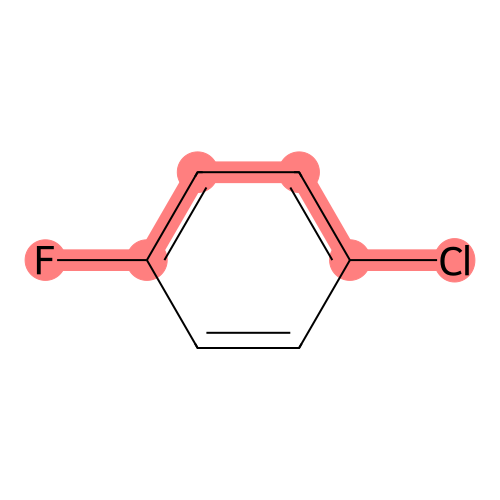

In [85]:
# SVG 파일을 그림으로 그리고 싶을때
from IPython.display import SVG
SVG(d.GetDrawingText())

### 3-3) SVB 파일로 저장

In [86]:
with open("data/a.svg", "w") as fp:
    fp.write(d.GetDrawingText())

## 4. 원자와 결합에 주석 달기
> atomNote와 bondNote 라는 이름의 property를 지정함으로서 표시 가능

In [87]:
mol = Chem.MolFromSmiles('Cl[C@H](F)NC\C=C\C')

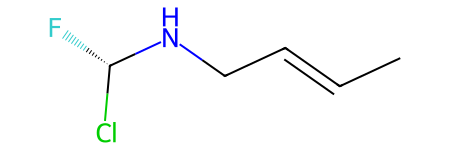

In [88]:
mol

In [89]:
d = rdMolDraw2D.MolDraw2DCairo(250, 200) # PNG 파일로 만들겠다. 
mol.GetAtomWithIdx(2).SetProp('atomNote', 'foo')   # 2번 atom의 atomNote라는 property를 foo로 정의
mol.GetBondWithIdx(0).SetProp('bondNote', 'bar')   # 0번에 해당하는 bond의 bondNote라는 property를 bar로 정의
d.drawOptions().addStereoAnnotation = True   # 옵션: addStereoAnnotation를 통해 이성질 표기
d.drawOptions().addAtomIndices = True     # 옵션: addAtomIndices를 통해 atom index 표기
d.DrawMolecule(mol)     # d(PNG file로 변환된 분자)를 실제 draw
d.FinishDrawing()     # d 마치기
d.WriteDrawingText('data/atom_annotation_1.png')     # PNG file의 경우 전과 다게 WriteDrawingTex()를 사용하여 파일 생성